# FAERS Dataset — NICHD Age Group Analysis

สรุปลักษณะทั่วไปของ ICSR แยกตามกลุ่มอายุ **NICHD** ภายในกลุ่ม Pediatric
และเปรียบเทียบกับกลุ่ม **Adult**

| | |
|---|---|
| NICHD Groups | Infancy · Toddler · Early childhood · Middle childhood · Early adolescence · Late adolescence |
| Output CSV | `overview_v2.csv` |
| Output PNG | `overview_adult_subped.png` |

---
**Table of Contents**
1. Data Loading
2. Deduplication
3. Data Exploration
4. NICHD Group Setup
5. Helper Functions
6. Normalisation
7. Summary Table
8. Export


## 1 — Data Loading

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

PED_PATH   = '../data/output/Pediatric/patient_report_reporter_drug_reaction_full_data.parquet'
ADULT_PATH = '../data/output/Adult/patient_report_reporter_drug_reaction_full_data.parquet'

ped   = pd.read_parquet(PED_PATH)
adult = pd.read_parquet(ADULT_PATH)

print(f'Pediatric : {ped.shape[0]:>12,} rows  x  {ped.shape[1]} cols')
print(f'Adult     : {adult.shape[0]:>12,} rows  x  {adult.shape[1]} cols')


Pediatric :      953,037 rows  x  34 cols
Adult     :   17,813,299 rows  x  33 cols


## 2 — Deduplication

> **หมายเหตุสำคัญ:** ไฟล์ parquet มี **1 row ต่อ (safetyreportid, drug, reaction)**  
> ดังนั้น 1 report ที่มีหลายยา/หลาย reaction จะมีหลาย row  
> การวิเคราะห์ระดับ **patient** ต้อง **dedup** ก่อน  
> การนับ **ICSR counts** (One/Multiple products per ICSR) ต้องใช้ **full data** (non-dedup)

| DataFrame | ความหมาย | ใช้กับ |
|---|---|---|
| `ped_r` / `adult_r` | 1 row per report (dedup) | patient-level analysis |
| `ped` / `adult` (raw) | all rows (original) | สร้าง `group_dfs_full` |


In [12]:
# 1 row per safetyreportid — for patient-level analysis
ped_r   = ped.drop_duplicates('safetyreportid').reset_index(drop=True)
adult_r = adult.drop_duplicates('safetyreportid').reset_index(drop=True)

ped_rpp   = len(ped)   / len(ped_r)
adult_rpp = len(adult) / len(adult_r)

print(f'Pediatric : {len(ped):>12,} rows  →  {len(ped_r):>8,} reports  (avg {ped_rpp:.1f} rows/report)')
print(f'Adult     : {len(adult):>12,} rows  →  {len(adult_r):>8,} reports  (avg {adult_rpp:.1f} rows/report)')


Pediatric :      953,037 rows  →   221,182 reports  (avg 4.3 rows/report)
Adult     :   17,813,299 rows  →  2,506,379 reports  (avg 7.1 rows/report)


## 3 — Data Exploration

ตรวจสอบโครงสร้างข้อมูลและการกระจายของ NICHD groups

In [13]:
# Columns and null counts
print('=== Columns ===')
print(ped.columns.tolist())

print('\n=== Null counts (Pediatric) ===')
null_ped = ped.isnull().sum()
print(null_ped[null_ped > 0].to_string())


=== Columns ===
['safetyreportid', 'age_years', 'patient_sex', 'nichd', 'receive_date', 'mostrecent_receive_date', 'lastupdate_date', 'serious', 'congenital_anomali', 'death', 'disabling', 'hospitalization', 'life_threatening', 'other', 'reporter_country', 'reporter_company', 'reporter_qualification', 'medicinal_product', 'rxcui', 'mapping_method', 'ingredient', 'faers_ingredients', 'ingredient_count', 'faers_ingredient_count', 'is_combination_product', 'drug_characterization', 'drug_administration', 'drug_indication', 'reaction_meddrapt', 'reaction_outcome', 'meddra_concept_id', 'meddra_concept_code', 'meddra_soc_codes', 'meddra_soc_names']

=== Null counts (Pediatric) ===
Series([], )


In [14]:
# NICHD distribution in Pediatric full data
print('=== NICHD distribution (ped_r, deduplicated) ===')
nichd_counts = ped_r['nichd'].value_counts(dropna=False)
nichd_total  = len(ped_r)
for k, v in nichd_counts.items():
    print(f'  {str(k):<25}  {v:>8,}  ({v/nichd_total*100:.1f}%)')

print(f'  {"Total":<25}  {nichd_total:>8,}')


=== NICHD distribution (ped_r, deduplicated) ===
  early_adolescence            72,516  (32.8%)
  late_adolescence             53,992  (24.4%)
  middle_childhood             42,247  (19.1%)
  early_childhood              28,090  (12.7%)
  infancy                      16,068  (7.3%)
  toddler                       8,269  (3.7%)
  Total                       221,182


## 4 — NICHD Group Setup

สร้าง DataFrame สำหรับแต่ละกลุ่ม NICHD + Adult สองชุด:

| ชุดข้อมูล | ที่มา | ใช้กับ |
|---|---|---|
| `group_dfs` | `ped_r` (dedup) + `adult_r` | patient-level sections (gender, qualification, serious outcomes) |
| `group_dfs_full` | `ped` (full) + `adult` (full) | ICSR-count sections (One/Multiple per ICSR) |


In [15]:
# NICHD label → internal value mapping
NICHD_MAP = {
    "Infancy":           "infancy",
    "Toddler":           "toddler",
    "Early childhood":   "early_childhood",
    "Middle childhood":  "middle_childhood",
    "Early adolescence": "early_adolescence",
    "Late adolescence":  "late_adolescence",
}

group_order = list(NICHD_MAP.keys()) + ["Adult"]

# Deduplicated — for patient-level sections
group_dfs = {g: ped_r[ped_r["nichd"] == v].copy() for g, v in NICHD_MAP.items()}
group_dfs["Adult"] = adult_r.copy()

# Full row-level — for ICSR-count sections
group_dfs_full = {g: ped[ped["nichd"] == v].copy() for g, v in NICHD_MAP.items()}
group_dfs_full["Adult"] = adult.copy()

print(f'Group order: {group_order}')
print('\nReports per group (deduplicated):')
for g in group_order:
    n = group_dfs[g]['safetyreportid'].nunique()
    print(f'  {g:<25}  {n:>8,}')


Group order: ['Infancy', 'Toddler', 'Early childhood', 'Middle childhood', 'Early adolescence', 'Late adolescence', 'Adult']

Reports per group (deduplicated):
  Infancy                      16,068
  Toddler                       8,269
  Early childhood              28,090
  Middle childhood             42,247
  Early adolescence            72,516
  Late adolescence             53,992
  Adult                      2,506,379


## 5 — Helper Functions

ฟังก์ชัน `_multi` รองรับ dictionary of DataFrames สำหรับทุก NICHD group

| ฟังก์ชัน | หน้าที่ |
|---|---|
| `format_count_pct` | แปลง count → `'N (X.X%)'` |
| `make_binary_count` | นับ row ที่ flag = 1 |
| `make_total_row_multi` | row: Number of ICRSs |
| `make_section_from_column_multi` | categorical column ทุก group |
| `make_serious_outcome_section_multi` | 6 specific serious-outcome subtype flags |
| `make_serious_vs_non_section_multi` | report-level Serious vs Non-serious (`serious` column) |
| `make_section_from_icsr_counts_multi` | One/Multiple items per ICSR |
| `prettify_summary` | ซ่อน section label ที่ซ้ำเพื่อแสดงผล |


In [16]:
# ── Format helpers ─────────────────────────────────────────────────────

def format_count_pct(count: int, total: int) -> str:
    """Return 'N (X.X%)' formatted string."""
    pct = (count / total * 100) if total > 0 else 0
    return f"{int(count):,} ({pct:.1f}%)"


def _to_binary(v) -> int:
    """Coerce 0/1/True/False/Y/N/str → int 0 or 1."""
    if pd.isna(v):
        return 0
    if isinstance(v, (bool, np.bool_)):
        return int(v)
    if isinstance(v, str):
        return 1 if v.strip().lower() in {"1", "y", "yes", "true", "t"} else 0
    try:
        return 1 if float(v) == 1 else 0
    except (TypeError, ValueError):
        return 0


def make_binary_count(series: pd.Series) -> int:
    """Count rows where binary flag = 1."""
    return int(series.map(_to_binary).sum())


# ── Section builders ────────────────────────────────────────────────────

def make_total_row_multi(
    group_dfs: dict,
    group_order: list,
) -> pd.DataFrame:
    """Number of ICRSs — deduplicated (1 row per report)."""
    row = {"section": "Number of ICRSs", "item": ""}
    for g in group_order:
        row[g] = f"{group_dfs[g]['safetyreportid'].nunique():,}"
    return pd.DataFrame([row])


def _count_pct_series(
    df: pd.DataFrame,
    col: str,
    categories: list = None,
    fillna_label: str = "Null/unknown",
) -> pd.DataFrame:
    """Frequency table with count + formatted 'N (X.X%)' for one column."""
    s = df[col].copy()
    if s.dtype == "O" or str(s.dtype).startswith("category"):
        s = s.fillna(fillna_label)
    counts = s.value_counts(dropna=False)
    if categories is not None:
        counts = counts.reindex(categories, fill_value=0)
    total = len(s)
    pct   = counts / total * 100 if total > 0 else counts * 0
    out = pd.DataFrame({"item": counts.index, "count": counts.values, "percent": pct.values})
    out["formatted"] = out.apply(lambda r: format_count_pct(int(r["count"]), total), axis=1)
    return out[["item", "formatted"]]


def make_section_from_column_multi(
    group_dfs: dict,
    group_order: list,
    col: str,
    section_name: str,
    categories: list = None,
    fillna_label: str = "Null/unknown",
) -> pd.DataFrame:
    """Compare one categorical column across all groups."""
    merged = None
    for g in group_order:
        tbl = _count_pct_series(
            group_dfs[g], col, categories, fillna_label
        ).rename(columns={"formatted": g})
        merged = tbl if merged is None else merged.merge(tbl, on="item", how="outer")
    merged.insert(0, "section", section_name)
    return merged


def make_serious_outcome_section_multi(
    group_dfs: dict,
    group_order: list,
    section_name: str = "Serious outcome reported",
) -> pd.DataFrame:
    """Six FAERS serious-outcome subtype flags (death, hospitalization, …).

    Counts are independent (one report can contribute to several rows).
    The report-level `serious` 0/1 field is **not** included here — use
    `make_serious_vs_non_section_multi` for Serious vs Non-serious.
    """
    OUTCOME_COLS = [
        ("death",              "Death"),
        ("hospitalization",    "Hospitalization"),
        ("life_threatening",   "Life threatening"),
        ("disabling",          "Disability"),
        ("congenital_anomali", "Congenital anomaly"),
        ("other",              "Other serious"),
    ]
    rows = []
    for col, label in OUTCOME_COLS:
        row = {"section": section_name, "item": label}
        for g in group_order:
            count = make_binary_count(group_dfs[g][col])
            total = len(group_dfs[g])
            row[g] = format_count_pct(count, total)
        rows.append(row)
    return pd.DataFrame(rows)


def make_serious_vs_non_section_multi(
    group_dfs: dict,
    group_order: list,
    section_name: str = "Serious vs non-serious",
) -> pd.DataFrame:
    """Report-level FAERS `serious` flag (0 = non-serious, 1 = serious).

    This is the overall case classification, not a MedDRA outcome subtype.
    """
    rows = []
    for item, mask_fn in [
        ("Serious",     lambda df: df["serious"] == 1),
        ("Non-serious", lambda df: df["serious"] == 0),
    ]:
        row = {"section": section_name, "item": item}
        for g in group_order:
            n = int(mask_fn(group_dfs[g]).sum())
            row[g] = format_count_pct(n, len(group_dfs[g]))
        rows.append(row)
    return pd.DataFrame(rows)


def _count_per_icsr(
    df: pd.DataFrame,
    id_col: str,
    value_col: str,
) -> pd.DataFrame:
    """Per-report unique count of value_col → classify as One / Multiple.

    Must use full (non-dedup) data so multiple drugs/reactions per report are visible.
    """
    per_report = (
        df[[id_col, value_col]]
        .dropna(subset=[id_col, value_col])
        .drop_duplicates()
        .groupby(id_col)[value_col]
        .nunique()
    )
    labels = pd.Series(
        np.where(per_report == 1, "One", "Multiple"),
        index=per_report.index,
    )
    total  = len(labels)
    counts = labels.value_counts().reindex(["One", "Multiple"], fill_value=0)
    out = pd.DataFrame({"item": counts.index, "count": counts.values})
    out["formatted"] = out["count"].apply(lambda x: format_count_pct(x, total))
    return out[["item", "formatted"]]


def make_section_from_icsr_counts_multi(
    group_dfs: dict,
    group_order: list,
    id_col: str,
    value_col: str,
    section_name: str,
) -> pd.DataFrame:
    """One / Multiple items per ICSR.  Must use FULL (non-dedup) group_dfs."""
    merged = None
    for g in group_order:
        tbl = _count_per_icsr(
            group_dfs[g], id_col=id_col, value_col=value_col
        ).rename(columns={"formatted": g})
        merged = tbl if merged is None else merged.merge(tbl, on="item", how="outer")
    merged.insert(0, "section", section_name)
    return merged


def prettify_summary(df: pd.DataFrame) -> pd.DataFrame:
    """Blank out repeated section labels for display (CSV export stays intact)."""
    out = df.copy()
    out["section"] = out["section"].mask(out["section"].duplicated(), "")
    return out


print('Helper functions defined.')


Helper functions defined.


## 6 — Normalisation

- `patient_sex`: map to **Female / Male / Unknown**
- `reporter_country`: map to **United States / Foreign**
- `reporter_qualification`: map to standard labels

สร้าง clean columns (`_clean` suffix) ใน `group_dfs` (deduplicated)


In [17]:
# ── patient_sex: Female / Male / Unknown ────────────────────────────────
def normalise_sex(series: pd.Series) -> pd.Series:
    def _map(v):
        if pd.isna(v):
            return "Unknown"
        vv = str(v).strip().upper()
        if vv in {"F", "2", "FEMALE"}:
            return "Female"
        if vv in {"M", "1", "MALE"}:
            return "Male"
        return "Unknown"
    return series.map(_map)


# ── reporter_country: United States / Foreign ────────────────────────────
_US_VARIANTS = {"US", "USA", "UNITED STATES", "UNITED STATES OF AMERICA"}

def normalise_country(series: pd.Series) -> pd.Series:
    def _map(v):
        if pd.isna(v):
            return "Null/unknown"
        return "United States" if str(v).strip().upper() in _US_VARIANTS else "Foreign"
    return series.map(_map)


# ── reporter_qualification ────────────────────────────────────────────────
_QUAL_MAP = {
    "PHYSICIAN":                  "Physician",
    "PHARMACIST":                 "Pharmacist",
    "OTHER HEALTH-PROFESSIONAL":  "Other health professional",
    "OTHER HEALTH PROFESSIONAL":  "Other health professional",
    "LAWYER":                     "Lawyer",
    "CONSUMER":                   "Consumer or non-health professional",
    "NON-HEALTH PROFESSIONAL":    "Consumer or non-health professional",
}

def normalise_qualification(series: pd.Series) -> pd.Series:
    def _map(v):
        if pd.isna(v):
            return "Null/unknown"
        vv = str(v).strip().upper()
        return _QUAL_MAP.get(vv, str(v).strip())
    return series.map(_map)


# ── Apply to all groups (only group_dfs — patient-level data) ────────────
for g in group_order:
    group_dfs[g]["patient_sex_clean"]             = normalise_sex(group_dfs[g]["patient_sex"])
    group_dfs[g]["reporter_country_clean"]         = normalise_country(group_dfs[g]["reporter_country"])
    group_dfs[g]["reporter_qualification_clean"]   = normalise_qualification(group_dfs[g]["reporter_qualification"])

print('Normalisation done.')
print('\nGender distribution (Pediatric — Infancy):')
print(group_dfs['Infancy']['patient_sex_clean'].value_counts().to_string())


Normalisation done.

Gender distribution (Pediatric — Infancy):
Male       8326
Female     6342
Unknown    1400


## 7 — Summary Table

ตารางสรุปลักษณะทั่วไป (Table 1) แยกตามกลุ่ม NICHD:

1. Number of ICRSs
2. Gender
3. Reporter country
4. Reporter qualification
5. Serious outcome reported (six subtype flags) + Serious vs non-serious
6. Suspect products per ICSR (นับ `rxcui` แทน `medicinal_product`)
7. Adverse events per ICSR


In [18]:
# ── Determine reporter_qualification categories ────────────────────────
_QUAL_ORDER = [
    "Physician",
    "Pharmacist",
    "Other health professional",
    "Consumer or non-health professional",
    "Lawyer",
    "Null/unknown",
]
_all_quals = pd.Index(
    pd.concat(
        [group_dfs[g]["reporter_qualification_clean"] for g in group_order],
        ignore_index=True,
    ).dropna().unique()
)
_extra_quals    = sorted(q for q in _all_quals if q not in _QUAL_ORDER)
qual_categories = [q for q in _QUAL_ORDER if q in _all_quals] + _extra_quals

# ── Build summary sections ─────────────────────────────────────────────
summary_parts = []

# 1. Number of ICRSs (deduplicated)
summary_parts.append(make_total_row_multi(group_dfs, group_order))

# 2. Gender
summary_parts.append(make_section_from_column_multi(
    group_dfs, group_order,
    col="patient_sex_clean",
    section_name="Gender",
    categories=["Female", "Male", "Unknown"],
))

# 3. Reporter country
summary_parts.append(make_section_from_column_multi(
    group_dfs, group_order,
    col="reporter_country_clean",
    section_name="Reporter country",
    categories=["Foreign", "United States"],
))

# 4. Reporter qualification
summary_parts.append(make_section_from_column_multi(
    group_dfs, group_order,
    col="reporter_qualification_clean",
    section_name="Reporter qualification",
    categories=qual_categories,
))

# 5. Six specific serious-outcome subtype flags
summary_parts.append(make_serious_outcome_section_multi(
    group_dfs, group_order,
    section_name="Serious outcome reported",
))

# 5b. Report-level Serious vs Non-serious (`serious` column)
summary_parts.append(make_serious_vs_non_section_multi(
    group_dfs, group_order,
    section_name="Serious vs non-serious",
))

# 6. Suspect products per ICSR — rxcui collapses brand-name duplicates
#    Must use group_dfs_full (full row-level data per group)
summary_parts.append(make_section_from_icsr_counts_multi(
    group_dfs_full, group_order,
    id_col="safetyreportid",
    value_col="rxcui",
    section_name="Suspect product reported per ICSR",
))

# 7. Adverse events per ICSR
#    Must use group_dfs_full (full row-level data per group)
summary_parts.append(make_section_from_icsr_counts_multi(
    group_dfs_full, group_order,
    id_col="safetyreportid",
    value_col="reaction_meddrapt",
    section_name="Adverse event reported per ICSR",
))

# ── Combine and display ───────────────────────────────────────────────
summary_df = pd.concat(summary_parts, ignore_index=True)
display_df = prettify_summary(summary_df)
display_df


,section,item,Infancy,Toddler,Early childhood,Middle childhood,Early adolescence,Late adolescence,Adult
0,Number of ICRSs,,"16,068","8,269","28,090","42,247","72,516","53,992","2,506,379"
1,Gender,Female,"6,342 (39.5%)","3,486 (42.2%)","11,715 (41.7%)","18,035 (42.7%)","37,862 (52.2%)","31,082 (57.6%)","1,424,874 (56.8%)"
2,,Male,"8,326 (51.8%)","4,390 (53.1%)","14,976 (53.3%)","22,797 (54.0%)","32,573 (44.9%)","21,797 (40.4%)","1,039,260 (41.5%)"
3,,Unknown,"1,400 (8.7%)",393 (4.8%),"1,399 (5.0%)","1,415 (3.3%)","2,081 (2.9%)","1,113 (2.1%)","42,245 (1.7%)"
4,Reporter country,Foreign,"10,936 (68.1%)","4,495 (54.4%)","15,285 (54.4%)","21,938 (51.9%)","38,255 (52.8%)","26,488 (49.1%)","1,279,815 (51.1%)"
5,,United States,"5,132 (31.9%)","3,774 (45.6%)","12,805 (45.6%)","20,309 (48.1%)","34,261 (47.2%)","27,504 (50.9%)","1,226,564 (48.9%)"
6,Reporter qualification,Physician,"7,453 (46.4%)","3,608 (43.6%)","12,651 (45.0%)","19,592 (46.4%)","33,592 (46.3%)","23,470 (43.5%)","1,062,979 (42.4%)"
7,,Pharmacist,"1,315 (8.2%)",664 (8.0%),"2,053 (7.3%)","3,422 (8.1%)","6,107 (8.4%)","5,123 (9.5%)","375,325 (15.0%)"
8,,Other health professional,"7,300 (45.4%)","3,997 (48.3%)","13,386 (47.7%)","19,233 (45.5%)","32,817 (45.3%)","25,399 (47.0%)","1,068,075 (42.6%)"
9,Serious outcome reported,Death,"2,233 (13.9%)",959 (11.6%),"2,192 (7.8%)","2,324 (5.5%)","4,008 (5.5%)","3,514 (6.5%)","323,534 (12.9%)"


## 8 — Export

บันทึก summary table เป็น PNG และ CSV


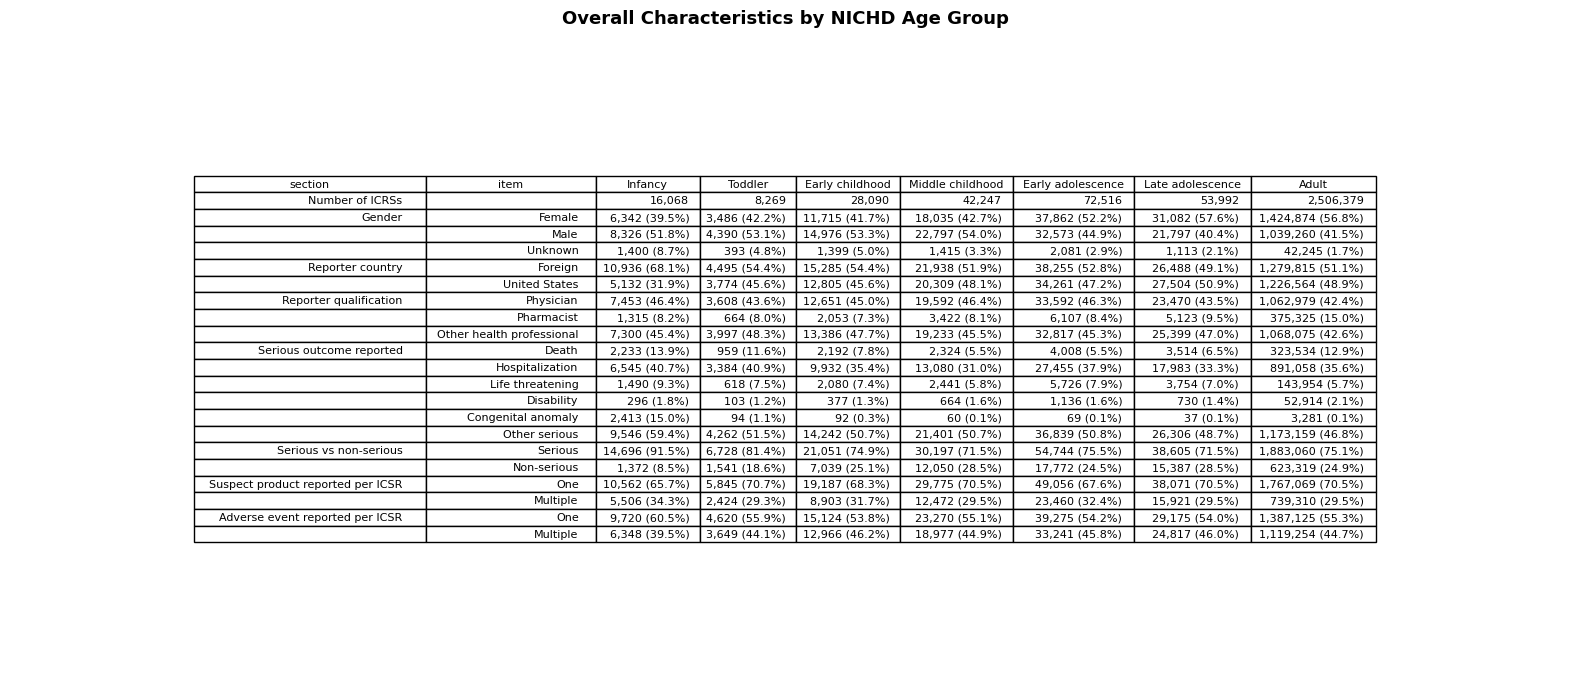

Saved: overview_adult_subped.png


In [19]:
# ── PNG: render table with matplotlib ──────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 8))
ax.axis('off')
tbl = ax.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    loc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.auto_set_column_width(col=list(range(len(display_df.columns))))
plt.title('Overall Characteristics by NICHD Age Group', pad=20, fontsize=13, fontweight='bold')
plt.savefig('output/figures/overview_adult_subped.png', bbox_inches='tight', dpi=300)
plt.show()
print('Saved: overview_adult_subped.png')


In [20]:
# ── CSV: export summary_df (with all section labels intact) ────────────
summary_df.to_csv('output/csv/overview_v2.csv', index=False)
print('Saved: overview_v2.csv')

# Quick verification
check = pd.read_csv('output/csv/overview_v2.csv')
print(f'Rows: {len(check)}  Cols: {check.shape[1]}')
print(check.to_string(index=False))


Saved: overview_v2.csv
Rows: 21  Cols: 9
                          section                      item        Infancy       Toddler Early childhood Middle childhood Early adolescence Late adolescence             Adult
                  Number of ICRSs                       NaN         16,068         8,269          28,090           42,247            72,516           53,992         2,506,379
                           Gender                    Female  6,342 (39.5%) 3,486 (42.2%)  11,715 (41.7%)   18,035 (42.7%)    37,862 (52.2%)   31,082 (57.6%) 1,424,874 (56.8%)
                           Gender                      Male  8,326 (51.8%) 4,390 (53.1%)  14,976 (53.3%)   22,797 (54.0%)    32,573 (44.9%)   21,797 (40.4%) 1,039,260 (41.5%)
                           Gender                   Unknown   1,400 (8.7%)    393 (4.8%)    1,399 (5.0%)     1,415 (3.3%)      2,081 (2.9%)     1,113 (2.1%)     42,245 (1.7%)
                 Reporter country                   Foreign 10,936 (68.1%) 4,495 (54